# 05 · Democratic waves and polling-error scenarios

Compare the **main Gaussian Bayesian model** with **20% and 50% corrected-polling mean blends**. These are sensitivities, not newly trained models or probabilities that a scenario occurs.

- **Wave +4 pp:** add four points to every state's D-minus-R final margin, beyond the current forecast. This is not four percentage points of Democratic vote share, and is not conditioning on the fitted national latent factor.
- **Polling error +2 pp:** polls overstate Democrats by two points beyond the learned historical correction. Subtract two from current poll margins, updating through the Gaussian likelihood. Negative errors favor Democrats. Unpolled states have no direct poll shock but can respond through covariance.
- Deterministic scenarios preserve the Bayesian covariance. Random scenarios add **extra** zero-mean error and therefore widen uncertainty; existing uncertainty already includes polling error.

Uses the latest **saved live run**, without downloading. Run notebook 04 first when you want newer evidence. Units and assumptions: [SCENARIOS.md](../docs/SCENARIOS.md).

In [2]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),Path.cwd().parent] if (p/'election_lab.py').exists())
sys.path.insert(0,str(ROOT))
import election_lab as lab
from release_scenarios import run
WEIGHTS=(0.,.20,.50)  # helper weights; zero is the Bayesian main
WAVES=range(11)      # additional D-minus-R margin points
ERRORS=range(-5,6)   # polls minus truth: positive means pro-D polling error
RUN=lab.run_logged(run,weights=WEIGHTS,waves=WAVES,errors=ERRORS)
meta=json.loads((RUN/'run.json').read_text())
seats=pd.read_parquet(RUN/'seats.parquet')
print('Evidence cutoff:',meta['as_of'],'| Source:',meta['source'])
print('Inherited stale sources:',meta['freshness'].get('stale_sources',[]))
print('Output:',RUN.relative_to(ROOT))
MODELS=['Bayesian','Corrected 20%','Corrected 50%']


Run log: cache/logs/run_20260921T035017.814030Z.txt
Evidence cutoff: 2026-09-20 | Source: outputs/live/20260921T034858.755021Z
Inherited stale sources: ['fred']
Output: outputs/scenarios/20260921T035017.953059Z


## Selected scenarios

Each cell below is **expected D seats / probability of D control**. Control requires at least 51 seats. The separate table includes point seats and the central 70% seat range. A 51-seat point count need not imply a control probability above 50%.

In [3]:
cases=[('Baseline',0,0,'none',0),('D wave +2',2,0,'none',0),('D wave +4',4,0,'none',0),
       ('D wave +6',6,0,'none',0),('D wave +10',10,0,'none',0),
       ('Polls understate D by 2',0,-2,'none',0),('Polls overstate D by 2',0,2,'none',0),
       ('Wave +2; polls overstate D by 2',2,2,'none',0),
       ('Random shared error: SD 2',0,0,'shared',2),('Random state error: SD 2',0,0,'independent',2)]
selected=[]
for label,w,e,mode,sd in cases:
    g=seats[(seats.wave_pp==w)&(seats.poll_error_pp==e)&(seats.random_mode==mode)&(seats.random_sd_pp==sd)].copy()
    g['case']=label;selected.append(g)
selected=pd.concat(selected,ignore_index=True)
selected['Expected D / control']=selected.apply(lambda x:f'{x.expected_D:.2f} / {100*x.p_D_control:.1f}%',axis=1)
selected['70% D seats']=selected.D_lo70.astype(str)+'–'+selected.D_hi70.astype(str)
display(selected.pivot(index='case',columns='model',values='Expected D / control').reindex([c[0] for c in cases])[MODELS])
display(selected[['case','model','point_D','point_R','expected_D','p_D_control','70% D seats']].round(3))


model,Bayesian,Corrected 20%,Corrected 50%
case,,,
Baseline,50.32 / 45.5%,50.03 / 38.3%,49.54 / 28.9%
D wave +2,51.53 / 75.7%,51.33 / 70.5%,50.99 / 61.8%
D wave +4,52.68 / 93.5%,52.56 / 91.3%,52.37 / 87.0%
D wave +6,53.80 / 99.0%,53.74 / 98.6%,53.66 / 97.5%
D wave +10,56.01 / 100.0%,55.98 / 100.0%,55.97 / 100.0%
Polls understate D by 2,51.17 / 67.6%,50.99 / 62.8%,50.69 / 55.0%
Polls overstate D by 2,49.45 / 24.6%,49.04 / 18.3%,48.39 / 11.1%
Wave +2; polls overstate D by 2,50.69 / 55.2%,50.38 / 46.6%,49.85 / 35.1%
Random shared error: SD 2,50.31 / 45.8%,50.02 / 40.0%,49.54 / 31.9%


,case,model,point_D,point_R,expected_D,p_D_control,70% D seats
0,Baseline,Bayesian,51,49,50.321,0.455,49–52
1,Baseline,Corrected 20%,51,49,50.032,0.383,48–52
2,Baseline,Corrected 50%,51,49,49.540,0.289,48–51
3,D wave +2,Bayesian,51,49,51.529,0.757,50–53
4,D wave +2,Corrected 20%,51,49,51.326,0.705,50–53
5,D wave +2,Corrected 50%,51,49,50.987,0.618,49–53
6,D wave +4,Bayesian,53,47,52.683,0.935,51–54
7,D wave +4,Corrected 20%,53,47,52.559,0.913,51–54
8,D wave +4,Corrected 50%,52,48,52.367,0.870,51–54
9,D wave +6,Bayesian,54,46,53.802,0.990,52–55


## Two-dimensional view

Columns are the additional Democratic wave; rows are polling error. The top row shows **P(D control)**, using the same 0–100% color scale. The bottom row shows **expected Democratic seats**, using a shared seat scale. Moving right adds a pro-D shift; moving toward positive polling error corrects a pro-D overstatement. These axes are not interchangeable because polling updates are moderated by the model and differ by state.

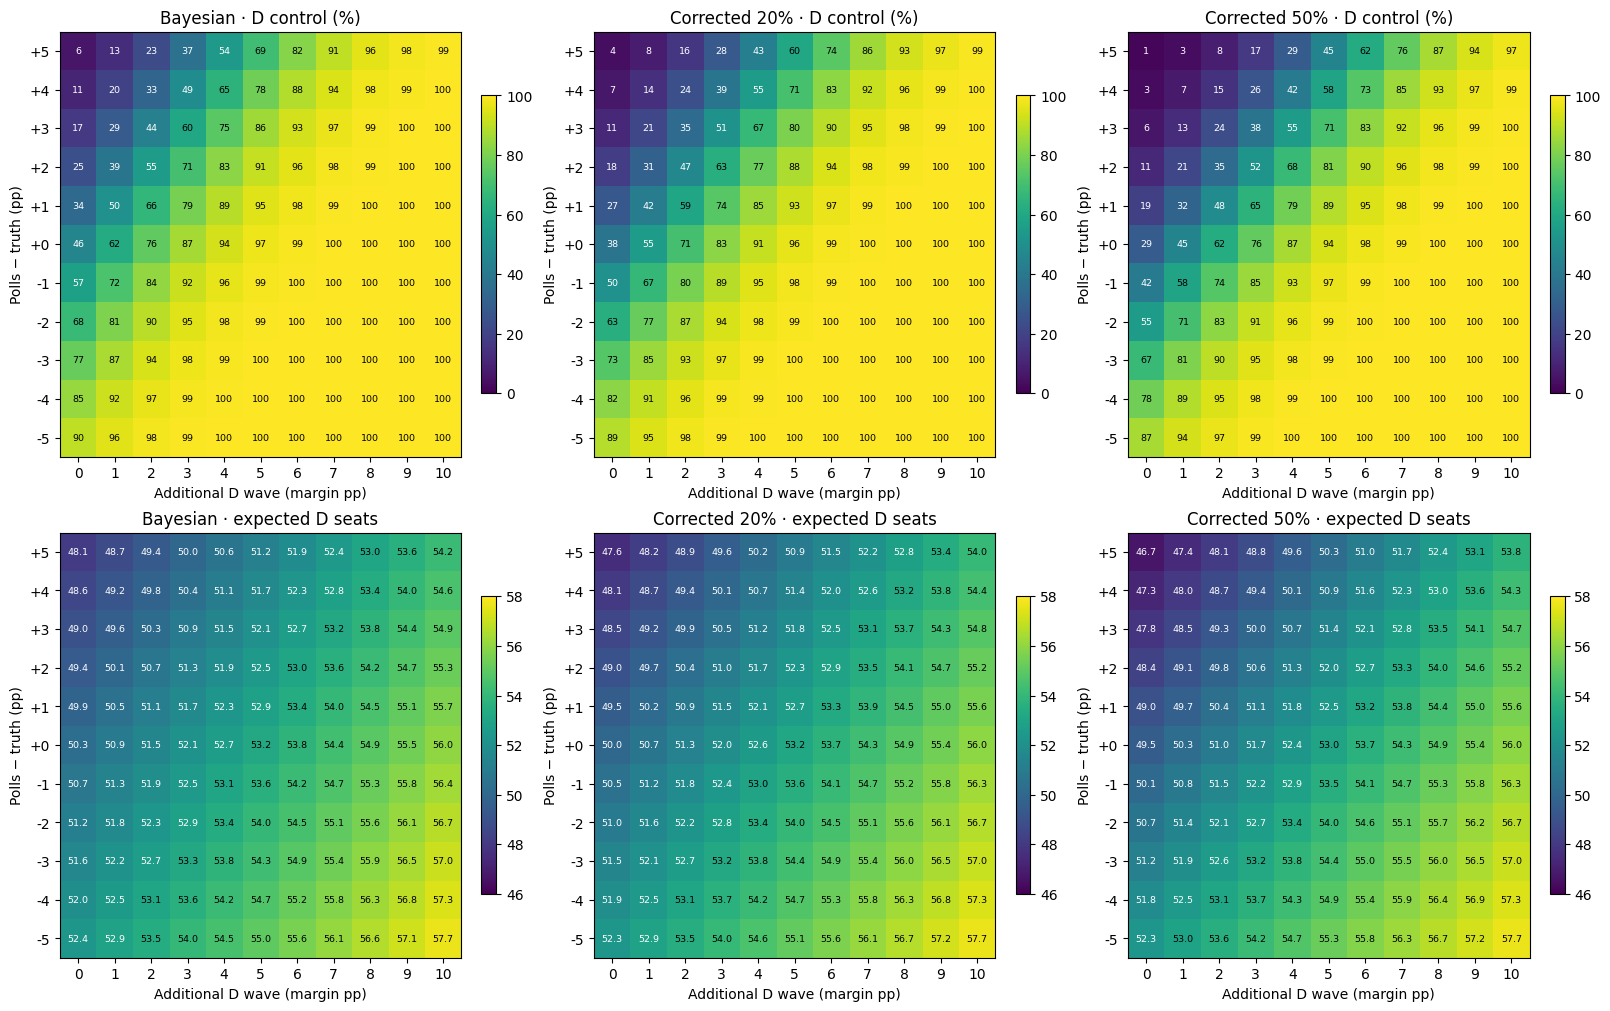

In [4]:
grid=seats[seats.random_mode.eq('none')]
fig,axes=plt.subplots(2,3,figsize=(16,10),constrained_layout=True)
for col,model in enumerate(MODELS):
    for row,metric in enumerate(['p_D_control','expected_D']):
        ax=axes[row,col]
        table=grid[grid.model.eq(model)].pivot(index='poll_error_pp',columns='wave_pp',values=metric).sort_index()
        values=table.to_numpy()*(100 if row==0 else 1)
        low,high=(0,100) if row==0 else (np.floor(grid.expected_D.min()),np.ceil(grid.expected_D.max()))
        im=ax.imshow(values,origin='lower',aspect='auto',vmin=low,vmax=high,cmap='viridis')
        ax.set(xticks=range(len(table.columns)),xticklabels=[f'{v:g}' for v in table.columns],
               yticks=range(len(table.index)),yticklabels=[f'{v:+g}' for v in table.index],
               xlabel='Additional D wave (margin pp)',ylabel='Polls − truth (pp)',
               title=model+' · '+('D control (%)' if row==0 else 'expected D seats'))
        for (i,j),value in np.ndenumerate(values):
            ax.text(j,i,f'{value:.0f}' if row==0 else f'{value:.1f}',ha='center',va='center',fontsize=6.8,
                    color='black' if (value-low)/(high-low)>.58 else 'white')
    fig.colorbar(axes[0,col].images[0],ax=axes[0,col],shrink=.7)
    fig.colorbar(axes[1,col].images[0],ax=axes[1,col],shrink=.7)
fig.savefig(RUN/'scenario_heatmaps.png',dpi=160)
plt.show()


## Random error: shared versus independent

A shared error draw moves every polled state's evidence in the same direction. Independent errors vary by state before propagating through the Bayesian update. Both are additional Gaussian stress terms with user-chosen SD 1–3 pp, not fitted distributions. They can change control probability in either direction, even though the mean margins do not change.

In [5]:
random=seats[seats.random_mode.ne('none')&seats.wave_pp.eq(0)].copy()
random['D control %']=100*random.p_D_control
random['70% D seats']=random.D_lo70.astype(str)+'–'+random.D_hi70.astype(str)
display(random[['model','random_mode','random_sd_pp','expected_D','D control %','70% D seats']].round(2))


,model,random_mode,random_sd_pp,expected_D,D control %,70% D seats
121,Bayesian,shared,1.0,50.32,45.64,49–52
127,Bayesian,independent,1.0,50.32,45.68,49–52
133,Bayesian,shared,2.0,50.31,45.84,48–52
139,Bayesian,independent,2.0,50.31,45.57,49–52
145,Bayesian,shared,3.0,50.29,46.18,48–52
151,Bayesian,independent,3.0,50.30,45.08,49–52
278,Corrected 20%,shared,1.0,50.03,38.75,48–52
284,Corrected 20%,independent,1.0,50.03,38.30,48–52
290,Corrected 20%,shared,2.0,50.02,39.97,48–52
296,Corrected 20%,independent,2.0,50.02,38.43,48–52


## State-level inspection

Change the three parameters below to inspect a deterministic cell in the heatmap. All 35 current contests remain present, including unpolled states. The poll-sensitivity table makes each state's response to one point of extra pro-D polling error visible.

In [6]:
VIEW_MODEL='Corrected 20%'
VIEW_WAVE=2
VIEW_ERROR=2
state=pd.read_parquet(RUN/'states.parquet')
view=state[(state.model==VIEW_MODEL)&(state.wave_pp==VIEW_WAVE)&(state.poll_error_pp==VIEW_ERROR)&state.random_mode.eq('none')].copy()
view['D win %']=100*view.p_dem
display(view[['geography','margin_pp','D win %','lo70_pp','hi70_pp']].round(2))
sensitivity=pd.read_csv(RUN/'poll_sensitivity.csv')
display(sensitivity.pivot(index='geography',columns='model',values='poll_error_response_pp_per_pp')[MODELS].round(3))


,geography,margin_pp,D win %,lo70_pp,hi70_pp
6510,AK,-2.42,34.12,-8.54,3.70
6511,AL,-21.26,0.06,-28.03,-14.48
6512,AR,-20.61,0.18,-27.96,-13.27
6513,CO,16.49,91.59,4.09,28.89
6514,DE,24.40,99.90,16.19,32.62
6515,FL,-5.74,19.15,-12.57,1.08
6516,GA,5.36,81.49,-0.84,11.55
6517,IA,-3.38,28.54,-9.55,2.80
6518,ID,-25.44,0.03,-33.10,-17.77
6519,IL,22.29,99.64,13.69,30.88


model,Bayesian,Corrected 20%,Corrected 50%
geography,,,
AK,-0.693,-0.755,-0.847
AL,-0.579,-0.663,-0.789
AR,-0.571,-0.657,-0.785
CO,-0.406,-0.325,-0.203
DE,-0.413,-0.331,-0.207
FL,-0.712,-0.769,-0.856
GA,-0.686,-0.749,-0.843
IA,-0.795,-0.836,-0.898
ID,-0.440,-0.352,-0.220


## Checks and interpretation

Zero stress reproduces the saved forecast. The likelihood response is checked against a direct Gaussian update; adding a uniform Democratic wave must never reduce expected D seats or control probability. Monte Carlo error for control probability is at most about 0.29 percentage points at 30,000 draws. Scenarios do not estimate how likely a wave/error is, and a 10-point uniform national shift is a large stress case.

In [7]:
# Register the generated figure in this run's immutable manifest.
lab.finish(RUN,meta)
lab.verify_run(RUN)
display(pd.DataFrame(meta['checks']))
print('Seat/state tables, sensitivities and heatmap saved in',RUN.relative_to(ROOT))


,model,zero_stress_reproduced,gaussian_response_verified
0,Bayesian,True,True
1,Corrected 20%,True,True
2,Corrected 50%,True,True


Seat/state tables, sensitivities and heatmap saved in outputs/scenarios/20260921T035017.953059Z
